# Garbage Classification dengan CNN

Proyek ini membangun model Convolutional Neural Network (CNN) untuk mengklasifikasikan jenis sampah ke dalam 6 kategori:
- **Glass** (Kaca)
- **Paper** (Kertas)
- **Cardboard** (Kardus)
- **Plastic** (Plastik)
- **Metal** (Logam)
- **Trash** (Sampah umum)

Dataset yang digunakan: [Garbage Classification Dataset](https://www.kaggle.com/datasets/asdasdasasdas/garbage-classification)

## 1. Import Library

In [133]:
import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import (
    Conv2D, MaxPooling2D, Flatten, Dense, Dropout,
    BatchNormalization, GlobalAveragePooling2D, Input
)
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam

from sklearn.metrics import classification_report, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight
import shutil
import random
import json

print(f'TensorFlow version: {tf.__version__}')
print(f'Keras version: {keras.__version__}')
print(f'GPU Available: {tf.config.list_physical_devices("GPU")}')


TensorFlow version: 2.16.2
Keras version: 3.14.0
GPU Available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## 2. Konfigurasi & Konstanta

In [134]:
# =============================================
# KONFIGURASI - Sesuaikan path dataset Anda
# =============================================

DATASET_DIR = 'Garbage_classification' 

BASE_DIR = 'dataset_split'
TRAIN_DIR = os.path.join(BASE_DIR, 'train')
VAL_DIR   = os.path.join(BASE_DIR, 'val')
TEST_DIR  = os.path.join(BASE_DIR, 'test')

IMG_SIZE    = (224, 224)
BATCH_SIZE  = 32
EPOCHS      = 350
LR          = 1e-4

TRAIN_RATIO = 0.70
TEST_RATIO  = 0.20
VAL_RATIO   = 0.10

CLASSES = ['cardboard', 'glass', 'metal', 'paper', 'plastic', 'trash']
NUM_CLASSES = len(CLASSES)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print('Konfigurasi:')
print(f'  Dataset dir : {DATASET_DIR}')
print(f'  Image size  : {IMG_SIZE}')
print(f'  Batch size  : {BATCH_SIZE}')
print(f'  Epochs      : {EPOCHS}')
print(f'  Num classes : {NUM_CLASSES}')
print(f'  Classes     : {CLASSES}')

Konfigurasi:
  Dataset dir : Garbage_classification
  Image size  : (224, 224)
  Batch size  : 32
  Epochs      : 350
  Num classes : 6
  Classes     : ['cardboard', 'glass', 'metal', 'paper', 'plastic', 'trash']


## 3. Eksplorasi Dataset

DISTRIBUSI DATASET
  cardboard   :   403 gambar
  glass       :   501 gambar
  metal       :   410 gambar
  paper       :   594 gambar
  plastic     :   482 gambar
  trash       :   137 gambar
------------------------------
  TOTAL       :  2527 gambar



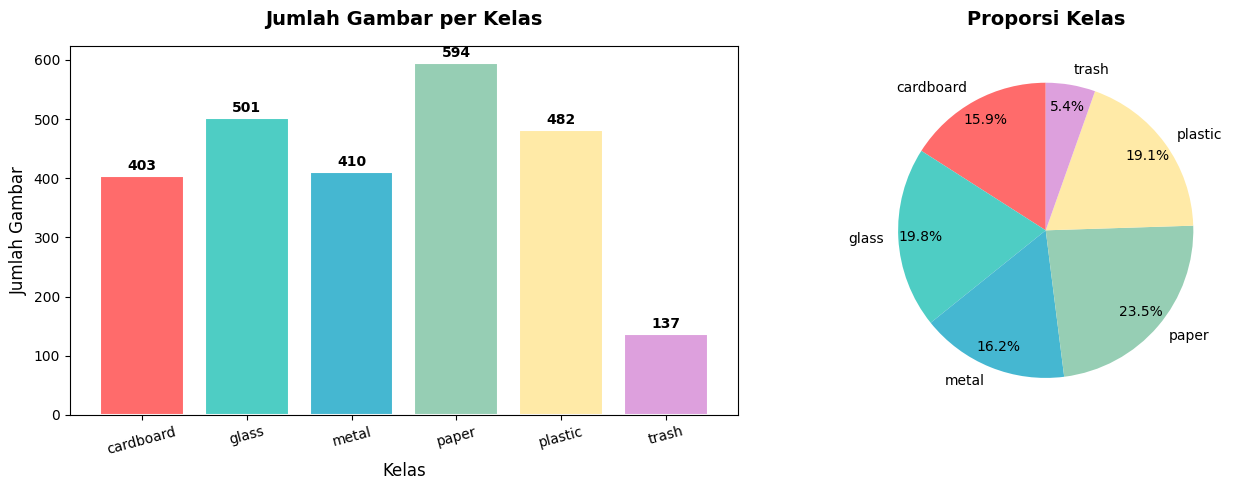

Plot distribusi kelas disimpan.


In [135]:
# Hitung jumlah gambar per kelas
print('=' * 50)
print('DISTRIBUSI DATASET')
print('=' * 50)

class_counts = {}
total_images = 0

for cls in CLASSES:
    cls_path = os.path.join(DATASET_DIR, cls)
    if os.path.exists(cls_path):
        count = len([f for f in os.listdir(cls_path) 
                     if f.lower().endswith(('.jpg', '.jpeg', '.png'))])
        class_counts[cls] = count
        total_images += count
        print(f'  {cls:<12}: {count:>5} gambar')
    else:
        print(f'  {cls:<12}: FOLDER TIDAK DITEMUKAN!')

print('-' * 30)
print(f'  {"TOTAL":<12}: {total_images:>5} gambar')
print()

# Visualisasi distribusi
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4', '#FFEAA7', '#DDA0DD']

# Bar chart
bars = axes[0].bar(class_counts.keys(), class_counts.values(), color=colors, edgecolor='white', linewidth=1.5)
axes[0].set_title('Jumlah Gambar per Kelas', fontsize=14, fontweight='bold', pad=15)
axes[0].set_xlabel('Kelas', fontsize=12)
axes[0].set_ylabel('Jumlah Gambar', fontsize=12)
axes[0].tick_params(axis='x', rotation=15)
for bar, count in zip(bars, class_counts.values()):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
                 str(count), ha='center', va='bottom', fontweight='bold')

# Pie chart
axes[1].pie(class_counts.values(), labels=class_counts.keys(), colors=colors,
            autopct='%1.1f%%', startangle=90, pctdistance=0.85)
axes[1].set_title('Proporsi Kelas', fontsize=14, fontweight='bold', pad=15)

plt.tight_layout()
plt.savefig('class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('Plot distribusi kelas disimpan.')

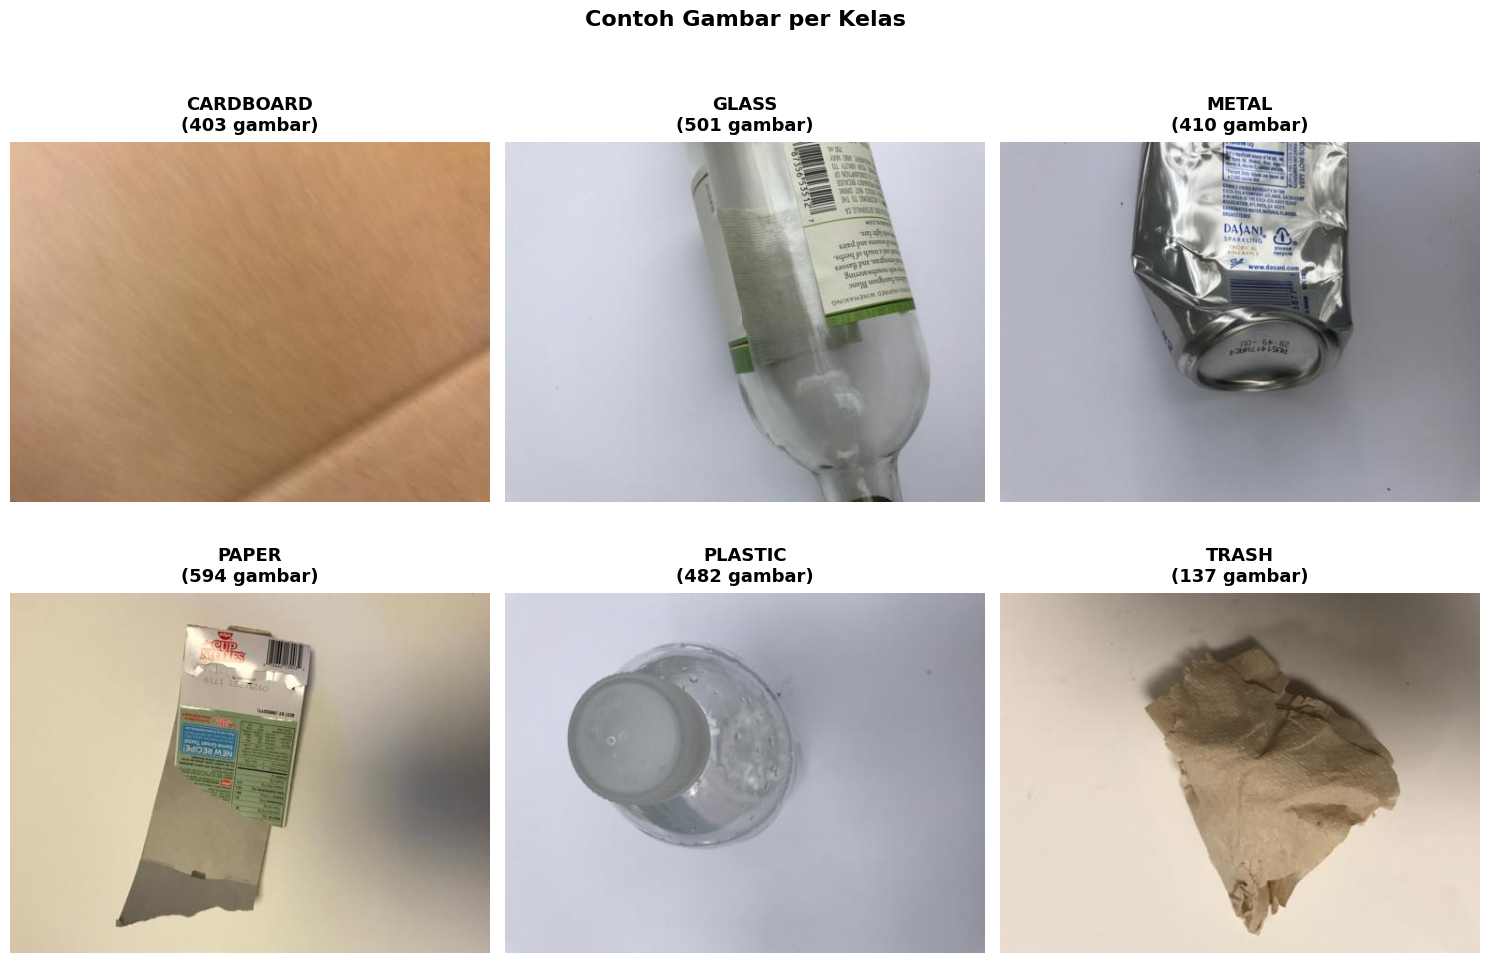

Plot contoh gambar disimpan.


In [136]:
# Tampilkan contoh gambar dari setiap kelas
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for idx, cls in enumerate(CLASSES):
    cls_path = os.path.join(DATASET_DIR, cls)
    if os.path.exists(cls_path):
        images = [f for f in os.listdir(cls_path)
                  if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
        if images:
            sample_img_path = os.path.join(cls_path, random.choice(images))
            img = mpimg.imread(sample_img_path)
            axes[idx].imshow(img)
            axes[idx].set_title(f'{cls.upper()}\n({class_counts.get(cls, 0)} gambar)',
                                fontsize=13, fontweight='bold', pad=8)
            axes[idx].axis('off')

plt.suptitle('Contoh Gambar per Kelas', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('sample_images.png', dpi=150, bbox_inches='tight')
plt.show()
print('Plot contoh gambar disimpan.')

## 4. Split Dataset (Train / Validation / Test)

Dataset dibagi dengan rasio: **70% Train | 10% Validation | 20% Test**

In [137]:
def split_dataset(src_dir, train_dir, val_dir, test_dir,
                  train_ratio=0.70, val_ratio=0.10, test_ratio=0.20,
                  seed=42):
    """
    Membagi dataset dari src_dir ke train/val/test.
    Struktur src_dir: src_dir/<class_name>/<image_files>
    """
    random.seed(seed)
    assert abs(train_ratio + val_ratio + test_ratio - 1.0) < 1e-6, \
        "Rasio train + val + test harus = 1.0"

    # Buat direktori output
    for split_dir in [train_dir, val_dir, test_dir]:
        os.makedirs(split_dir, exist_ok=True)

    split_summary = {}

    for cls in os.listdir(src_dir):
        cls_src = os.path.join(src_dir, cls)
        if not os.path.isdir(cls_src):
            continue

        # Kumpulkan semua file gambar
        images = [f for f in os.listdir(cls_src)
                  if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
        random.shuffle(images)

        n = len(images)
        n_train = int(n * train_ratio)
        n_val   = int(n * val_ratio)
        # Sisa masuk test
        n_test  = n - n_train - n_val

        splits = {
            train_dir: images[:n_train],
            val_dir  : images[n_train:n_train + n_val],
            test_dir : images[n_train + n_val:]
        }

        split_summary[cls] = {'train': n_train, 'val': n_val, 'test': n_test}

        for dest_dir, file_list in splits.items():
            cls_dest = os.path.join(dest_dir, cls)
            os.makedirs(cls_dest, exist_ok=True)
            for fname in file_list:
                src  = os.path.join(cls_src, fname)
                dest = os.path.join(cls_dest, fname)
                if not os.path.exists(dest):
                    shutil.copy2(src, dest)

    return split_summary


# Cek apakah split sudah ada
if os.path.exists(BASE_DIR):
    print(f'Direktori "{BASE_DIR}" sudah ada. Melewati proses split.')
    print('Jika ingin split ulang, hapus folder tersebut terlebih dahulu.')
else:
    print('Memulai proses split dataset...')
    summary = split_dataset(
        src_dir    = DATASET_DIR,
        train_dir  = TRAIN_DIR,
        val_dir    = VAL_DIR,
        test_dir   = TEST_DIR,
        train_ratio= TRAIN_RATIO,
        val_ratio  = VAL_RATIO,
        test_ratio = TEST_RATIO,
        seed       = SEED
    )

    print()
    print('=' * 55)
    print(f'{"KELAS":<14} {"TRAIN":>8} {"VAL":>8} {"TEST":>8} {"TOTAL":>8}')
    print('=' * 55)
    for cls, counts in summary.items():
        total = counts['train'] + counts['val'] + counts['test']
        print(f'{cls:<14} {counts["train"]:>8} {counts["val"]:>8} {counts["test"]:>8} {total:>8}')
    print('=' * 55)
    print('Split dataset selesai!')

Direktori "dataset_split" sudah ada. Melewati proses split.
Jika ingin split ulang, hapus folder tersebut terlebih dahulu.


In [138]:
# Verifikasi hasil split
print('Verifikasi jumlah file hasil split:')
print('=' * 40)

for split_name, split_path in [('TRAIN', TRAIN_DIR), ('VAL', VAL_DIR), ('TEST', TEST_DIR)]:
    total = 0
    print(f'\n[{split_name}] {split_path}')
    for cls in CLASSES:
        cls_path = os.path.join(split_path, cls)
        if os.path.exists(cls_path):
            n = len(os.listdir(cls_path))
            total += n
            print(f'  {cls:<12}: {n:>5}')
    print(f'  {"Total":<12}: {total:>5}')

Verifikasi jumlah file hasil split:

[TRAIN] dataset_split/train
  cardboard   :   282
  glass       :   350
  metal       :   287
  paper       :   415
  plastic     :   337
  trash       :    95
  Total       :  1766

[VAL] dataset_split/val
  cardboard   :    40
  glass       :    50
  metal       :    41
  paper       :    59
  plastic     :    48
  trash       :    13
  Total       :   251

[TEST] dataset_split/test
  cardboard   :    81
  glass       :   101
  metal       :    82
  paper       :   120
  plastic     :    97
  trash       :    29
  Total       :   510


## 5. Data Generator & Augmentasi

In [139]:
# =============================================
# Augmentasi lebih kuat untuk Training
# =============================================
train_datagen = ImageDataGenerator(
    rescale            = 1./255,
    rotation_range     = 30,
    width_shift_range  = 0.2,
    height_shift_range = 0.2,
    shear_range        = 0.15,
    zoom_range         = 0.2,
    horizontal_flip    = True,
    brightness_range   = [0.8, 1.2],
    channel_shift_range= 20.0,
    fill_mode          = 'nearest'
)

val_test_datagen = ImageDataGenerator(rescale=1./255)

# =============================================
# Generator
# =============================================
train_generator = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size = IMG_SIZE,
    batch_size  = BATCH_SIZE,
    class_mode  = 'categorical',
    shuffle     = True,
    seed        = SEED
)

val_generator = val_test_datagen.flow_from_directory(
    VAL_DIR,
    target_size = IMG_SIZE,
    batch_size  = BATCH_SIZE,
    class_mode  = 'categorical',
    shuffle     = False
)

test_generator = val_test_datagen.flow_from_directory(
    TEST_DIR,
    target_size = IMG_SIZE,
    batch_size  = BATCH_SIZE,
    class_mode  = 'categorical',
    shuffle     = False
)

# =============================================
# Class Weights untuk menangani imbalanced data
# =============================================
y_train = train_generator.classes
class_weights = compute_class_weight(
    class_weight = 'balanced',
    classes      = np.unique(y_train),
    y            = y_train
)
class_weight_dict = dict(enumerate(class_weights))

print()
print('Class indices:', train_generator.class_indices)
print(f'Train batches : {len(train_generator)}')
print(f'Val batches   : {len(val_generator)}')
print(f'Test batches  : {len(test_generator)}')
print()
print('Class weights (untuk handle imbalanced data):')
class_names_list = list(train_generator.class_indices.keys())
for idx, (cls, w) in enumerate(zip(class_names_list, class_weights)):
    print(f'  {cls:<12}: {w:.4f}')


Found 1766 images belonging to 6 classes.
Found 251 images belonging to 6 classes.
Found 510 images belonging to 6 classes.

Class indices: {'cardboard': 0, 'glass': 1, 'metal': 2, 'paper': 3, 'plastic': 4, 'trash': 5}
Train batches : 56
Val batches   : 8
Test batches  : 16

Class weights (untuk handle imbalanced data):
  cardboard   : 1.0437
  glass       : 0.8410
  metal       : 1.0256
  paper       : 0.7092
  plastic     : 0.8734
  trash       : 3.0982


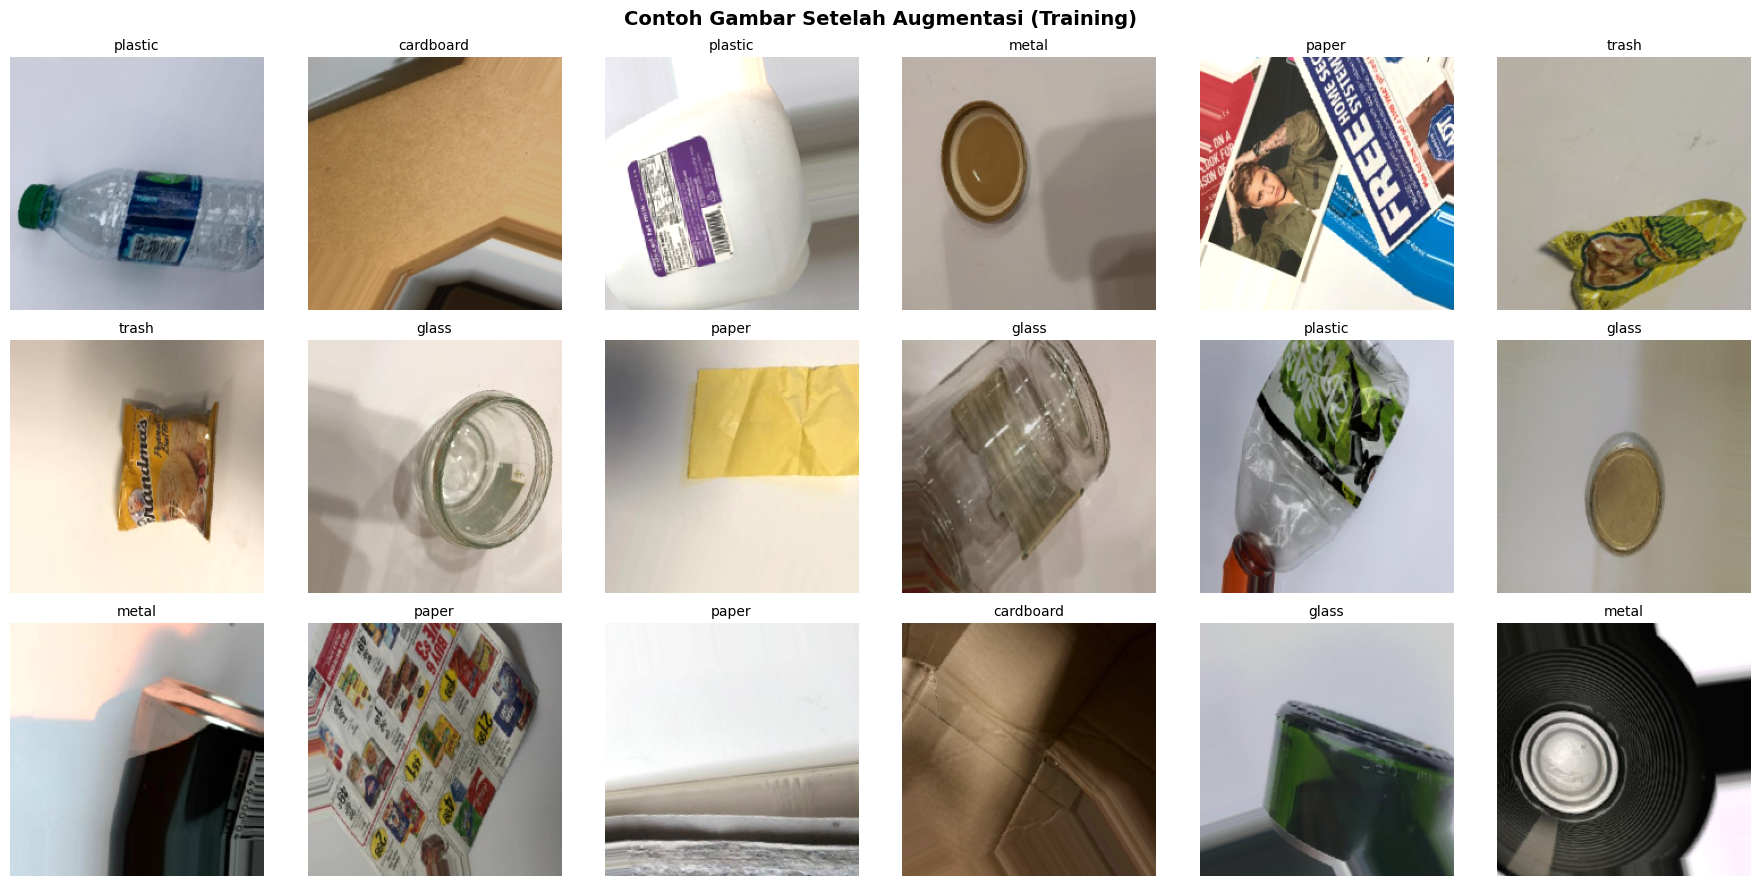

In [140]:
# Visualisasi gambar hasil augmentasi
sample_batch_imgs, sample_batch_labels = next(train_generator)

class_names = list(train_generator.class_indices.keys())

fig, axes = plt.subplots(3, 6, figsize=(18, 9))
axes = axes.flatten()

for i in range(min(18, len(sample_batch_imgs))):
    axes[i].imshow(sample_batch_imgs[i])
    label_idx = np.argmax(sample_batch_labels[i])
    axes[i].set_title(class_names[label_idx], fontsize=10)
    axes[i].axis('off')

plt.suptitle('Contoh Gambar Setelah Augmentasi (Training)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('augmented_samples.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Arsitektur Model CNN

Model dibangun menggunakan **Sequential API** dengan lapisan **Conv2D** dan **MaxPooling2D** sebagai feature extraction head, dilanjutkan dengan **EfficientNetV2S** sebagai transfer learning backbone.

Arsitektur:
- **3 Block Conv2D + MaxPooling2D** → memenuhi Kriteria 4
- **EfficientNetV2S** (frozen) → transfer learning dari ImageNet
- **GlobalAveragePooling2D + Dense layers** → klasifikasi


In [141]:
# =============================================
# Arsitektur Model CNN dengan Sequential + Conv2D + Pooling
# =============================================
from tensorflow.keras.applications import EfficientNetV2S

def build_sequential_model(input_shape=(224, 224, 3), num_classes=6):
    """
    Model CNN Sequential dengan Conv2D dan MaxPooling2D.
    Strategi: EfficientNetV2S menghasilkan feature map 7x7,
    lalu Conv2D + MaxPooling diterapkan pada feature map tersebut
    sebelum masuk ke Dense classifier.
    """
    # Load EfficientNetV2S (output: 7x7x1280 untuk input 224x224)
    base_model = EfficientNetV2S(
        include_top=False,
        weights='imagenet',
        input_shape=input_shape,
        include_preprocessing=False
    )
    base_model.trainable = False

    model = Sequential([
        # ----- Input + Transfer Learning Base -----
        Input(shape=input_shape),
        base_model,                              # output: (7, 7, 1280)

        # ----- Block Conv2D + MaxPooling2D pada feature map (Kriteria 4) -----
        # Block 1
        Conv2D(256, (3, 3), activation='relu', padding='same'),   # (7, 7, 256)
        MaxPooling2D(pool_size=(1, 1)),                            # (7, 7, 256) - preserve spatial

        # Block 2
        Conv2D(128, (3, 3), activation='relu', padding='same'),   # (7, 7, 128)
        MaxPooling2D(pool_size=(1, 1)),                            # (7, 7, 128)

        # Block 3
        Conv2D(64, (3, 3), activation='relu', padding='same'),    # (7, 7, 64)
        MaxPooling2D(pool_size=(7, 7)),                            # (1, 1, 64) -> flatten

        # ----- Head Klasifikasi -----
        Flatten(),
        Dense(512, activation='relu'),
        BatchNormalization(),
        Dropout(0.4),
        Dense(256, activation='relu'),
        Dropout(0.3),
        Dense(num_classes, activation='softmax')
    ], name='GarbageClassifier_Sequential_CNN')

    return model, base_model


model, base_model = build_sequential_model((*IMG_SIZE, 3), NUM_CLASSES)
model.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)
model.summary()


Model: "GarbageClassifier_Sequential_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ efficientnetv2-s (Functional)   │ (None, 7, 7, 1280)     │    20,331,360 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 7, 7, 256)      │     2,949,376 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 7, 7, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 7, 7, 128)      │       295,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_15 (Conv2D)              │ (None, 7, 7, 64)       │        73,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_12 (MaxPooling2D) │ (None, 1, 1, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 512)            │        33,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_14          │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_15 (Dropout)            │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_16 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_20 (Dense)                │ (None, 6)              │         1,542 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,817,766 (90.86 MB)

 Trainable params: 3,485,382 (13.30 MB)

 Non-trainable params: 20,332,384 (77.56 MB)

In [142]:
# FASE 1 - Training dengan base_model frozen
print("FASE 1: Training top layers (base frozen)...")
print("=" * 60)

os.makedirs('checkpoints', exist_ok=True)

history_phase1 = model.fit(
    train_generator,
    epochs=15,
    validation_data=val_generator,
    class_weight=class_weight_dict,
    verbose=1
)

print(f"\nFase 1 selesai!")
print(f"Train acc : {history_phase1.history['accuracy'][-1]:.4f}")
print(f"Val acc   : {history_phase1.history['val_accuracy'][-1]:.4f}")


FASE 1: Training top layers (base frozen)...
Epoch 1/15
56/56 ━━━━━━━━━━━━━━━━━━━━ 48s 522ms/step - accuracy: 0.3800 - loss: 2.2703 - val_accuracy: 0.3586 - val_loss: 5.6787
Epoch 2/15
56/56 ━━━━━━━━━━━━━━━━━━━━ 15s 264ms/step - accuracy: 0.5696 - loss: 1.6728 - val_accuracy: 0.5618 - val_loss: 2.3801
Epoch 3/15
56/56 ━━━━━━━━━━━━━━━━━━━━ 15s 264ms/step - accuracy: 0.6461 - loss: 1.4986 - val_accuracy: 0.6295 - val_loss: 1.9787
Epoch 4/15
56/56 ━━━━━━━━━━━━━━━━━━━━ 17s 301ms/step - accuracy: 0.6840 - loss: 1.1697 - val_accuracy: 0.7092 - val_loss: 1.1725
Epoch 5/15
56/56 ━━━━━━━━━━━━━━━━━━━━ 16s 281ms/step - accuracy: 0.6982 - loss: 1.1283 - val_accuracy: 0.6255 - val_loss: 2.0501
Epoch 6/15
56/56 ━━━━━━━━━━━━━━━━━━━━ 15s 259ms/step - accuracy: 0.7463 - loss: 0.9977 - val_accuracy: 0.7371 - val_loss: 0.9165
Epoch 7/15
56/56 ━━━━━━━━━━━━━━━━━━━━ 15s 271ms/step - accuracy: 0.7475 - loss: 1.0080 - val_accuracy: 0.8167 - val_loss: 0.5947
Epoch 8/15
56/56 ━━━━━━━━━━━━━━━━━━━━ 15s 272ms/step

In [143]:
# FASE 2 - Fine-tuning: unfreeze 100 layer terakhir base_model
print("FASE 2: Selective fine-tuning (100 layer terakhir base model)...")
print("=" * 60)

base_model.trainable = True
for layer in base_model.layers[:-100]:
    layer.trainable = False

trainable_count = sum(1 for l in base_model.layers if l.trainable)
print(f"Layer base yang di-unfreeze : {trainable_count} dari {len(base_model.layers)}")

model.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

callbacks = [
    EarlyStopping(
        monitor='val_accuracy',
        patience=20,
        restore_best_weights=True,
        min_delta=0.001,
        verbose=1
    ),
    ModelCheckpoint(
        filepath='checkpoints/best_model.keras',
        monitor='val_accuracy',
        save_best_only=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_accuracy',
        factor=0.3,
        patience=7,
        min_lr=1e-9,
        verbose=1
    )
]

history_phase2 = model.fit(
    train_generator,
    epochs=80,
    validation_data=val_generator,
    callbacks=callbacks,
    class_weight=class_weight_dict,
    verbose=1
)

print(f"\nTrain acc terbaik : {max(history_phase2.history['accuracy']):.4f}")
print(f"Val acc terbaik   : {max(history_phase2.history['val_accuracy']):.4f}")


FASE 2: Selective fine-tuning (100 layer terakhir base model)...
Layer base yang di-unfreeze : 100 dari 512
Epoch 1/80
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 688ms/step - accuracy: 0.7468 - loss: 0.8323
Epoch 1: val_accuracy improved from None to 0.75697, saving model to checkpoints/best_model.keras

Epoch 1: finished saving model to checkpoints/best_model.keras
56/56 ━━━━━━━━━━━━━━━━━━━━ 73s 861ms/step - accuracy: 0.7333 - loss: 0.8897 - val_accuracy: 0.7570 - val_loss: 0.7819 - learning_rate: 1.0000e-05
Epoch 2/80
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 404ms/step - accuracy: 0.7785 - loss: 0.7241
Epoch 2: val_accuracy did not improve from 0.75697
56/56 ━━━━━━━━━━━━━━━━━━━━ 26s 451ms/step - accuracy: 0.7809 - loss: 0.7077 - val_accuracy: 0.7570 - val_loss: 0.6963 - learning_rate: 1.0000e-05
Epoch 3/80
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 432ms/step - accuracy: 0.7573 - loss: 0.7480
Epoch 3: val_accuracy improved from 0.75697 to 0.78088, saving model to checkpoints/best_model.keras

Epoch 3: finished saving mo

## 7. Plot Akurasi & Loss

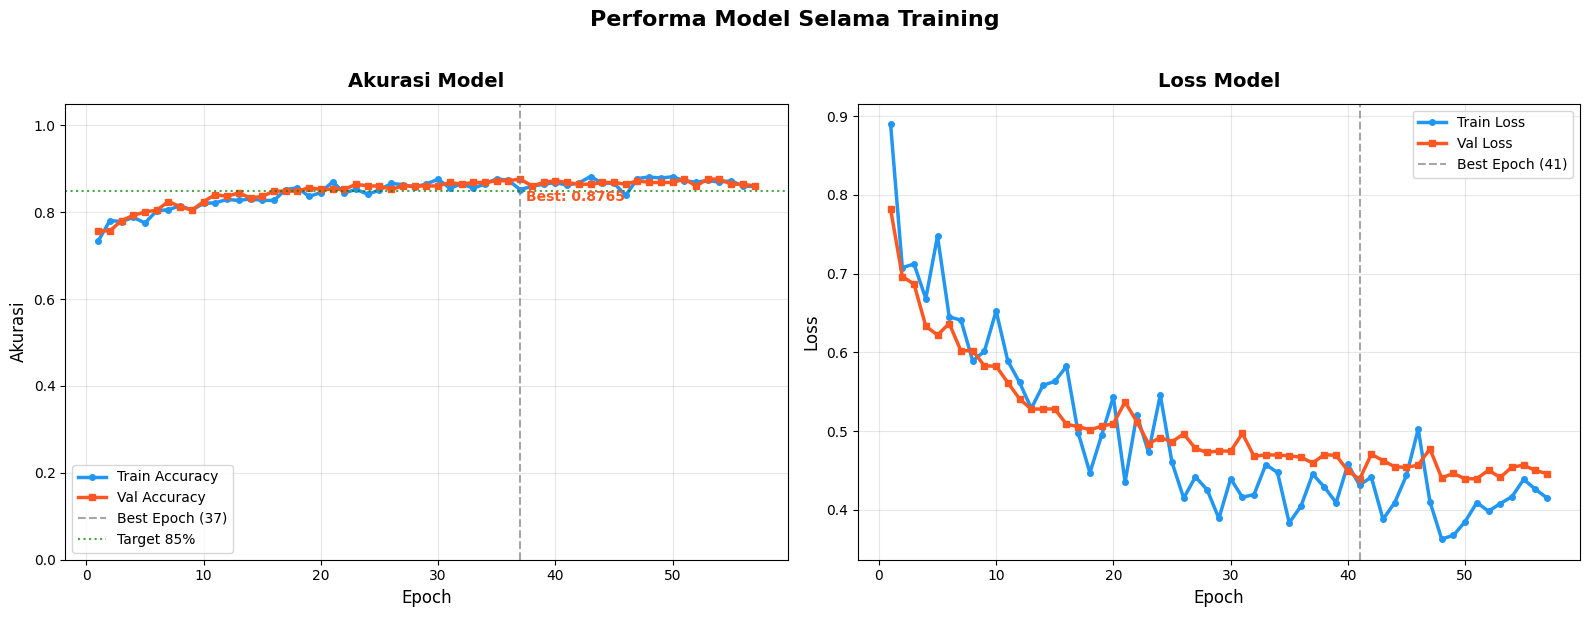

Plot training history disimpan ke: training_history.png


In [144]:
def plot_history(history, save_path='training_history.png'):
    """Plot akurasi dan loss selama training."""
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    epochs_range = range(1, len(history.history['accuracy']) + 1)

    # ---- Plot Akurasi ----
    ax1 = axes[0]
    ax1.plot(epochs_range, history.history['accuracy'],
             color='#2196F3', linewidth=2.5, marker='o', markersize=4, label='Train Accuracy')
    ax1.plot(epochs_range, history.history['val_accuracy'],
             color='#FF5722', linewidth=2.5, marker='s', markersize=4, label='Val Accuracy')

    best_val_acc_epoch = np.argmax(history.history['val_accuracy']) + 1
    best_val_acc = max(history.history['val_accuracy'])
    ax1.axvline(best_val_acc_epoch, color='gray', linestyle='--', alpha=0.7, label=f'Best Epoch ({best_val_acc_epoch})')
    ax1.axhline(0.85, color='green', linestyle=':', alpha=0.7, label='Target 85%')

    ax1.set_title('Akurasi Model', fontsize=14, fontweight='bold', pad=12)
    ax1.set_xlabel('Epoch', fontsize=12)
    ax1.set_ylabel('Akurasi', fontsize=12)
    ax1.legend(fontsize=10)
    ax1.grid(True, alpha=0.3)
    ax1.set_ylim([0, 1.05])
    ax1.annotate(f'Best: {best_val_acc:.4f}',
                 xy=(best_val_acc_epoch, best_val_acc),
                 xytext=(best_val_acc_epoch + 0.5, best_val_acc - 0.05),
                 fontsize=10, color='#FF5722', fontweight='bold')

    # ---- Plot Loss ----
    ax2 = axes[1]
    ax2.plot(epochs_range, history.history['loss'],
             color='#2196F3', linewidth=2.5, marker='o', markersize=4, label='Train Loss')
    ax2.plot(epochs_range, history.history['val_loss'],
             color='#FF5722', linewidth=2.5, marker='s', markersize=4, label='Val Loss')

    best_val_loss_epoch = np.argmin(history.history['val_loss']) + 1
    ax2.axvline(best_val_loss_epoch, color='gray', linestyle='--', alpha=0.7, label=f'Best Epoch ({best_val_loss_epoch})')

    ax2.set_title('Loss Model', fontsize=14, fontweight='bold', pad=12)
    ax2.set_xlabel('Epoch', fontsize=12)
    ax2.set_ylabel('Loss', fontsize=12)
    ax2.legend(fontsize=10)
    ax2.grid(True, alpha=0.3)

    plt.suptitle('Performa Model Selama Training', fontsize=16, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Plot training history disimpan ke: {save_path}')


plot_history(history_phase2)

## 8. Evaluasi Model

In [145]:
# =============================================
# Evaluasi pada Train Set
# =============================================
print('Mengevaluasi pada Training Set...')
train_eval_gen = val_test_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size = IMG_SIZE,
    batch_size  = BATCH_SIZE,
    class_mode  = 'categorical',
    shuffle     = False
)
train_loss, train_acc = model.evaluate(train_eval_gen, verbose=1)

# =============================================
# Evaluasi pada Validation Set
# =============================================
print('\nMengevaluasi pada Validation Set...')
val_loss, val_acc = model.evaluate(val_generator, verbose=1)

# =============================================
# Evaluasi pada Test Set
# =============================================
print('\nMengevaluasi pada Test Set...')
test_loss, test_acc = model.evaluate(test_generator, verbose=1)

print()
print('=' * 45)
print('RINGKASAN EVALUASI')
print('=' * 45)
print(f'{"Set":<12} {"Accuracy":>12} {"Loss":>10}')
print('-' * 45)
print(f'{"Train":<12} {train_acc:>11.4f} {train_loss:>10.4f}')
print(f'{"Validation":<12} {val_acc:>11.4f} {val_loss:>10.4f}')
print(f'{"Test":<12} {test_acc:>11.4f} {test_loss:>10.4f}')
print('=' * 45)

# Cek kriteria
print()
train_ok = '✅' if train_acc >= 0.85 else '❌'
test_ok  = '✅' if test_acc  >= 0.85 else '❌'
print(f'{train_ok} Train accuracy  : {train_acc*100:.2f}% (target ≥ 85%)')
print(f'{test_ok} Test accuracy   : {test_acc*100:.2f}% (target ≥ 85%)')

Mengevaluasi pada Training Set...
Found 1766 images belonging to 6 classes.
56/56 ━━━━━━━━━━━━━━━━━━━━ 16s 287ms/step - accuracy: 0.9632 - loss: 0.1245

Mengevaluasi pada Validation Set...
8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 251ms/step - accuracy: 0.8765 - loss: 0.4594

Mengevaluasi pada Test Set...
16/16 ━━━━━━━━━━━━━━━━━━━━ 8s 504ms/step - accuracy: 0.8510 - loss: 0.5553

RINGKASAN EVALUASI
Set              Accuracy       Loss
---------------------------------------------
Train             0.9632     0.1245
Validation        0.8765     0.4594
Test              0.8510     0.5553

✅ Train accuracy  : 96.32% (target ≥ 85%)
✅ Test accuracy   : 85.10% (target ≥ 85%)


16/16 ━━━━━━━━━━━━━━━━━━━━ 20s 703ms/step

Classification Report:
              precision    recall  f1-score   support

   cardboard       0.96      0.89      0.92        81
       glass       0.86      0.80      0.83       101
       metal       0.77      0.89      0.82        82
       paper       0.90      0.91      0.90       120
     plastic       0.84      0.82      0.83        97
       trash       0.63      0.66      0.64        29

    accuracy                           0.85       510
   macro avg       0.83      0.83      0.83       510
weighted avg       0.85      0.85      0.85       510



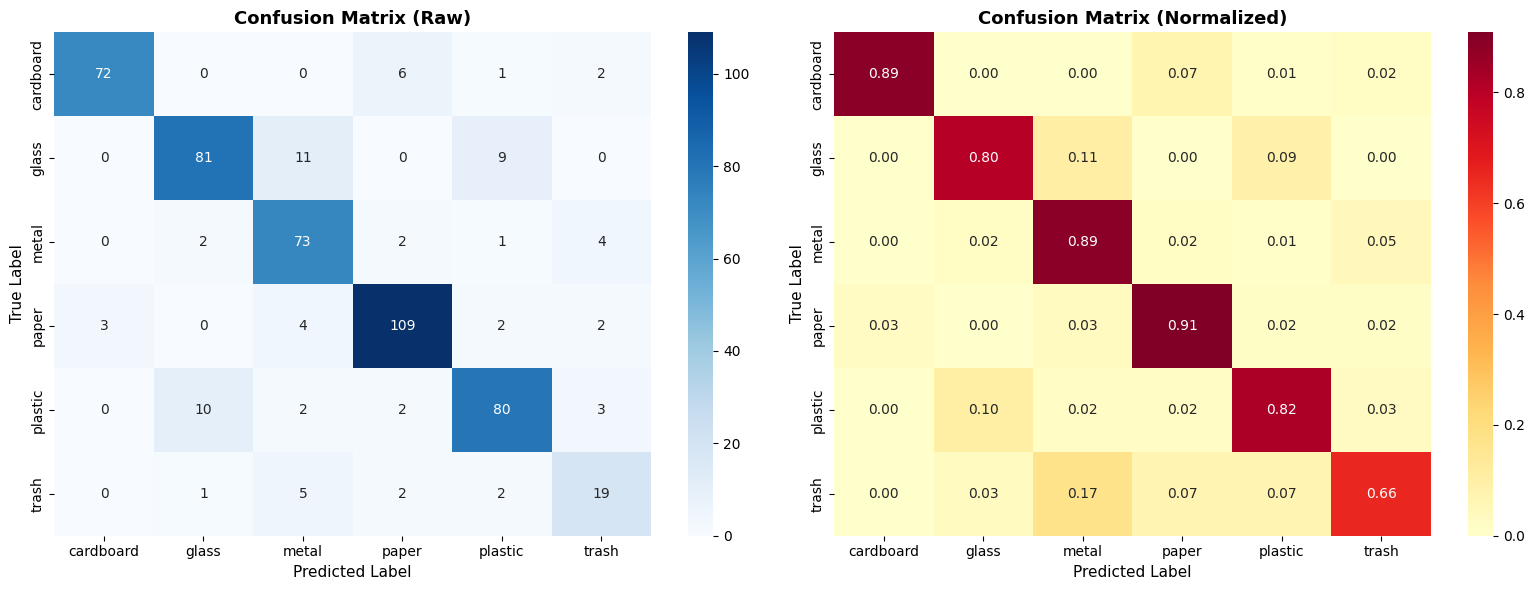

Confusion matrix disimpan.


In [146]:
# =============================================
# Confusion Matrix & Classification Report
# =============================================
test_generator.reset()
y_pred_proba = model.predict(test_generator, verbose=1)
y_pred = np.argmax(y_pred_proba, axis=1)
y_true = test_generator.classes
class_names = list(test_generator.class_indices.keys())

print('\nClassification Report:')
print('=' * 60)
print(classification_report(y_true, y_pred, target_names=class_names))

# Plot Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Raw confusion matrix
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names, ax=axes[0])
axes[0].set_title('Confusion Matrix (Raw)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Predicted Label', fontsize=11)
axes[0].set_ylabel('True Label', fontsize=11)

# Normalized confusion matrix
sns.heatmap(cm_normalized, annot=True, fmt='.2f', cmap='YlOrRd',
            xticklabels=class_names, yticklabels=class_names, ax=axes[1])
axes[1].set_title('Confusion Matrix (Normalized)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Predicted Label', fontsize=11)
axes[1].set_ylabel('True Label', fontsize=11)

plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print('Confusion matrix disimpan.')

Found 510 images belonging to 6 classes.


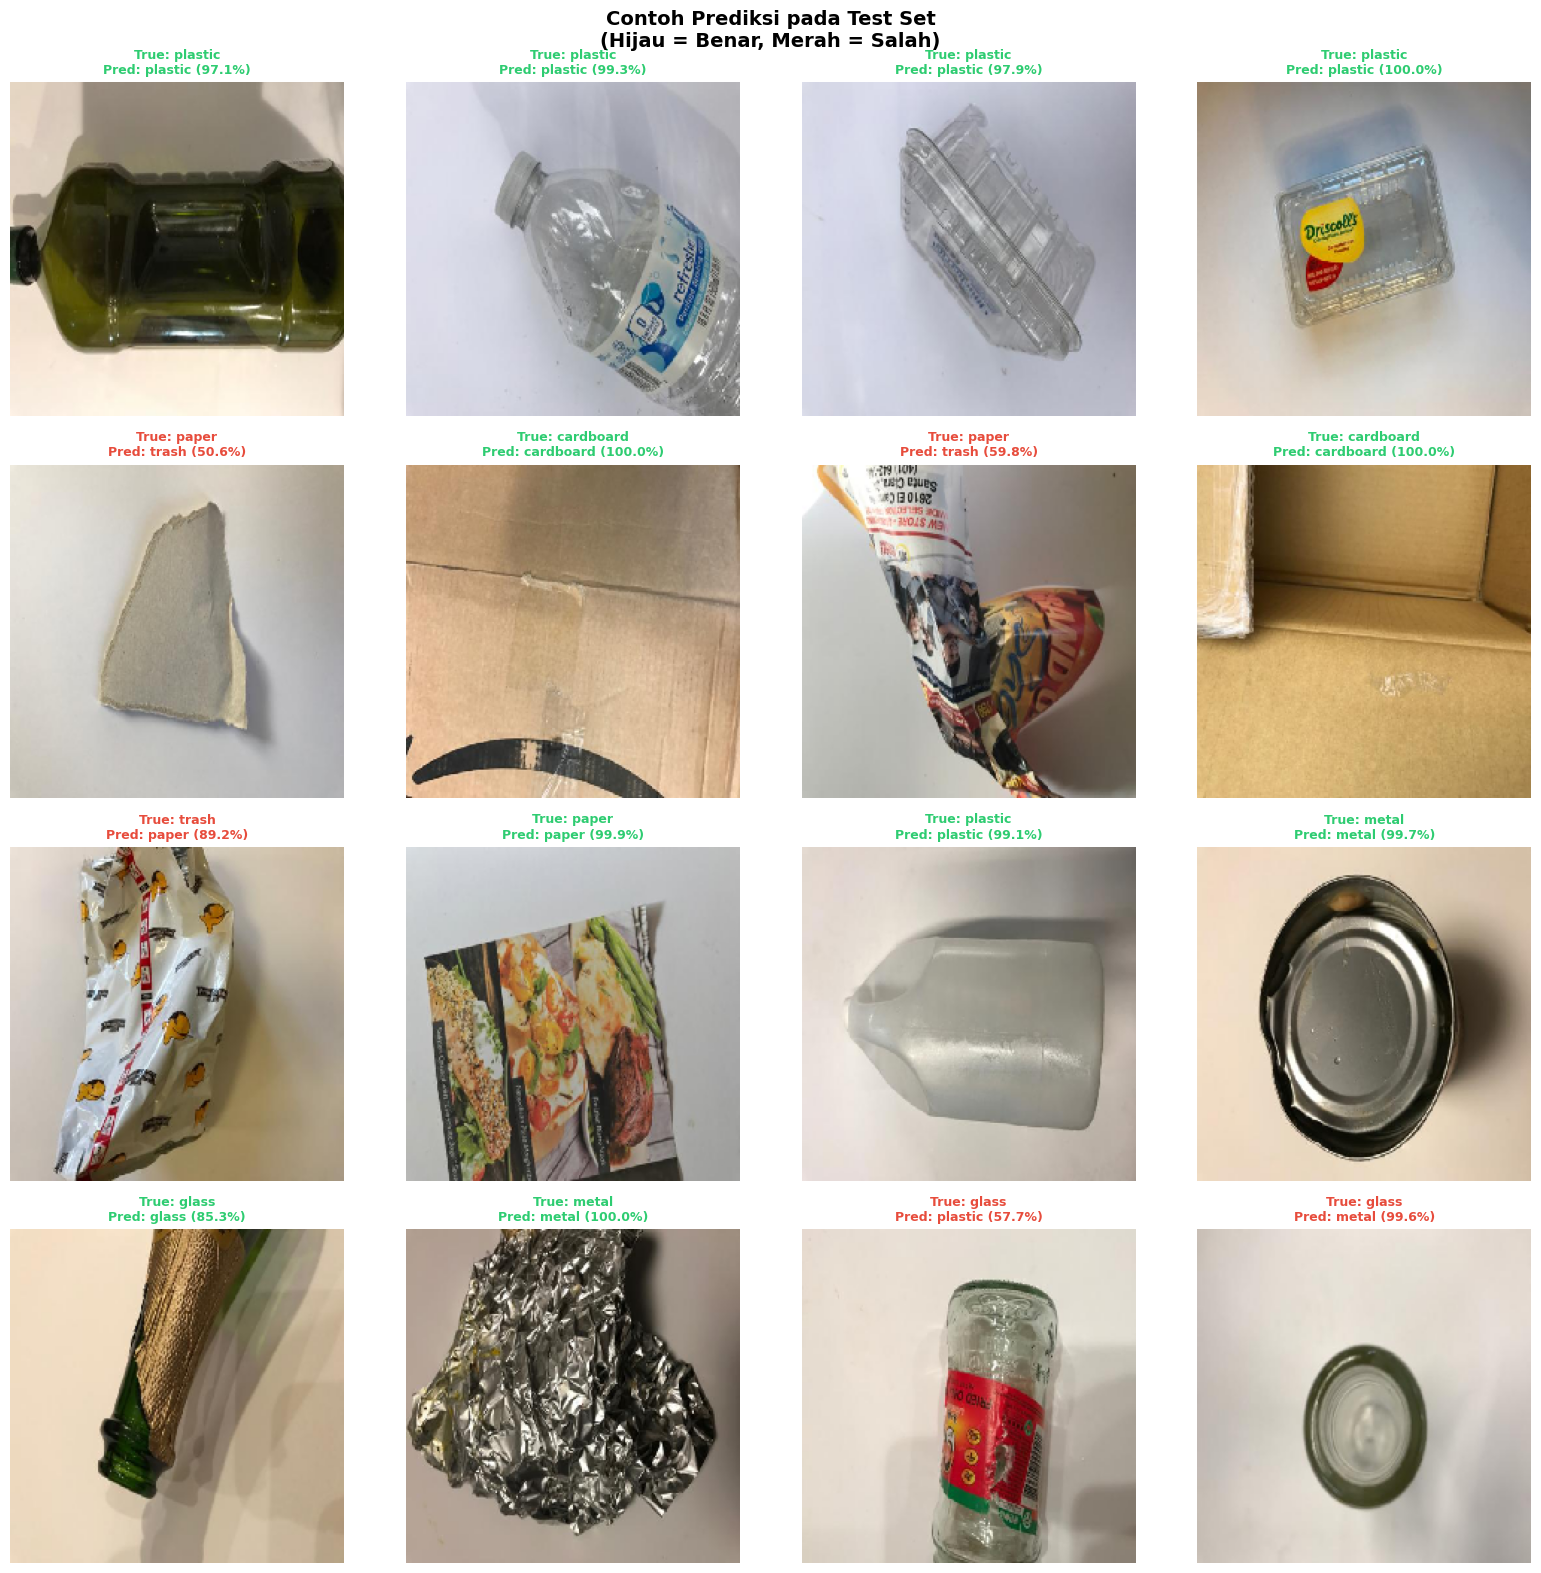

In [147]:
# Visualisasi prediksi pada beberapa gambar test
test_generator.reset()
test_imgs, test_labels_batch = next(val_test_datagen.flow_from_directory(
    TEST_DIR,
    target_size = IMG_SIZE,
    batch_size  = 16,
    class_mode  = 'categorical',
    shuffle     = True,
    seed        = SEED
))

preds = model.predict(test_imgs, verbose=0)
pred_labels = np.argmax(preds, axis=1)
true_labels = np.argmax(test_labels_batch, axis=1)

fig, axes = plt.subplots(4, 4, figsize=(16, 16))
axes = axes.flatten()

for i in range(16):
    axes[i].imshow(test_imgs[i])
    pred_cls = class_names[pred_labels[i]]
    true_cls = class_names[true_labels[i]]
    conf = preds[i][pred_labels[i]] * 100
    correct = pred_labels[i] == true_labels[i]
    color = '#2ECC71' if correct else '#E74C3C'
    axes[i].set_title(f'True: {true_cls}\nPred: {pred_cls} ({conf:.1f}%)',
                      fontsize=9, color=color, fontweight='bold')
    axes[i].axis('off')

plt.suptitle('Contoh Prediksi pada Test Set\n(Hijau = Benar, Merah = Salah)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('prediction_samples.png', dpi=150, bbox_inches='tight')
plt.show()

## 9. Simpan Model

Model disimpan dalam tiga format:
1. **SavedModel** - Format standar TensorFlow
2. **TF-Lite** - Untuk perangkat mobile/embedded
3. **TF.js** - Untuk browser dan JavaScript

In [148]:
# Buat folder output
os.makedirs('saved_model', exist_ok=True)
os.makedirs('tflite', exist_ok=True)
os.makedirs('tfjs_model', exist_ok=True)

# =============================================
# 1. Simpan sebagai SavedModel
# =============================================
print('=' * 50)
print('1. Menyimpan dalam format SavedModel...')
model.export('saved_model')
print('SavedModel disimpan di: ./saved_model/')

1. Menyimpan dalam format SavedModel...
INFO:tensorflow:Assets written to: saved_model/assets


INFO:tensorflow:Assets written to: saved_model/assets


Saved artifact at 'saved_model'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name='keras_tensor_3166')
Output Type:
  TensorSpec(shape=(None, 6), dtype=tf.float32, name=None)
Captures:
  16773787920: TensorSpec(shape=(), dtype=tf.resource, name=None)
  16773788976: TensorSpec(shape=(), dtype=tf.resource, name=None)
  16773786864: TensorSpec(shape=(), dtype=tf.resource, name=None)
  16773784576: TensorSpec(shape=(), dtype=tf.resource, name=None)
  16773786336: TensorSpec(shape=(), dtype=tf.resource, name=None)
  16773788624: TensorSpec(shape=(), dtype=tf.resource, name=None)
  16773783696: TensorSpec(shape=(), dtype=tf.resource, name=None)
  16773786512: TensorSpec(shape=(), dtype=tf.resource, name=None)
  16773784752: TensorSpec(shape=(), dtype=tf.resource, name=None)
  16773784928: TensorSpec(shape=(), dtype=tf.resource, name=None)
  16773786688: TensorSpec(shape=(), dtype=tf.resource, n

In [149]:
# =============================================
# 2. Simpan sebagai TF-Lite
# =============================================
print('=' * 50)
print('2. Mengkonversi ke format TF-Lite...')

converter = tf.lite.TFLiteConverter.from_saved_model('saved_model')
converter.optimizations = [tf.lite.Optimize.DEFAULT]  # Quantization
tflite_model = converter.convert()

tflite_path = 'tflite/model.tflite'
with open(tflite_path, 'wb') as f:
    f.write(tflite_model)

# Simpan label
label_path = 'tflite/label.txt'
with open(label_path, 'w') as f:
    for cls in class_names:
        f.write(cls + '\n')

tflite_size_mb = os.path.getsize(tflite_path) / (1024 * 1024)
print(f'✅ TF-Lite model disimpan di: {tflite_path}')
print(f'   Ukuran file: {tflite_size_mb:.2f} MB')
print(f'✅ Label disimpan di: {label_path}')
print(f'   Labels: {class_names}')

2. Mengkonversi ke format TF-Lite...


W0000 00:00:1778222383.302937 6514770 tf_tfl_flatbuffer_helpers.cc:390] Ignored output_format.
W0000 00:00:1778222383.303505 6514770 tf_tfl_flatbuffer_helpers.cc:393] Ignored drop_control_dependency.
2026-05-08 13:39:43.304839: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: saved_model
2026-05-08 13:39:43.318753: I tensorflow/cc/saved_model/reader.cc:51] Reading meta graph with tags { serve }
2026-05-08 13:39:43.318790: I tensorflow/cc/saved_model/reader.cc:146] Reading SavedModel debug info (if present) from: saved_model
2026-05-08 13:39:43.519096: I tensorflow/cc/saved_model/loader.cc:234] Restoring SavedModel bundle.
2026-05-08 13:39:44.203543: I tensorflow/cc/saved_model/loader.cc:218] Running initialization op on SavedModel bundle at path: saved_model
2026-05-08 13:39:44.376378: I tensorflow/cc/saved_model/loader.cc:317] SavedModel load for tags { serve }; Status: success: OK. Took 1071541 microseconds.


✅ TF-Lite model disimpan di: tflite/model.tflite
   Ukuran file: 24.31 MB
✅ Label disimpan di: tflite/label.txt
   Labels: ['cardboard', 'glass', 'metal', 'paper', 'plastic', 'trash']


In [150]:
# Verifikasi TF-Lite model
print('Memverifikasi TF-Lite model...')

interpreter = tf.lite.Interpreter(model_path=tflite_path)
interpreter.allocate_tensors()

input_details  = interpreter.get_input_details()
output_details = interpreter.get_output_details()

print(f'Input shape  : {input_details[0]["shape"]}')
print(f'Input dtype  : {input_details[0]["dtype"]}')
print(f'Output shape : {output_details[0]["shape"]}')
print(f'Output dtype : {output_details[0]["dtype"]}')

# Test inference dengan gambar dummy
dummy_input = np.random.rand(1, *IMG_SIZE, 3).astype(np.float32)
interpreter.set_tensor(input_details[0]['index'], dummy_input)
interpreter.invoke()
tflite_output = interpreter.get_tensor(output_details[0]['index'])
print(f'Test output shape : {tflite_output.shape}')
print(f'Test output sum   : {tflite_output.sum():.4f} (harus ~1.0)')
print('✅ TF-Lite model terverifikasi!')

Memverifikasi TF-Lite model...
Input shape  : [  1 224 224   3]
Input dtype  : <class 'numpy.float32'>
Output shape : [1 6]
Output dtype : <class 'numpy.float32'>
Test output shape : (1, 6)
Test output sum   : 1.0000 (harus ~1.0)
✅ TF-Lite model terverifikasi!


In [157]:
import os, sys

os.makedirs('tfjs_model', exist_ok=True)

print('=' * 50)
print('3. Mengkonversi ke format TensorFlow.js...')

model.export('saved_model')

os.system(f'{sys.executable} -m pip uninstall tensorflow_decision_forests -y -q')
os.system(f'{sys.executable} -m pip install tensorflowjs -q')

try:
    import importlib
    import tensorflowjs as tfjs
    importlib.reload(tfjs)
    from tensorflowjs.converters import convert_tf_saved_model

    convert_tf_saved_model(
        saved_model_dir='saved_model',
        output_dir='tfjs_model'
    )
    print('TF.js model berhasil disimpan di: ./tfjs_model/')
    print('\nIsi folder tfjs_model:')
    for f in sorted(os.listdir('tfjs_model')):
        size_kb = os.path.getsize(os.path.join('tfjs_model', f)) / 1024
        print(f'  {f} ({size_kb:.1f} KB)')

except Exception as e:
    print(f'⚠️ Python API gagal: {e}')
    print('Mencoba via command line dengan env bersih...')

    import subprocess
    env = os.environ.copy()
    env['PYTHONPATH'] = ''

    import shutil
    converter_path = shutil.which('tensorflowjs_converter')
    if not converter_path:
        import site
        for sp in site.getsitepackages():
            candidate = os.path.join(os.path.dirname(sp), 'bin', 'tensorflowjs_converter')
            if os.path.exists(candidate):
                converter_path = candidate
                break

    if converter_path:
        result = subprocess.run(
            [sys.executable, converter_path,
             '--input_format=tf_saved_model',
             '--output_format=tfjs_graph_model',
             'saved_model', 'tfjs_model'],
            capture_output=True, text=True, env=env
        )
        if result.returncode == 0:
            print('✅ Berhasil via fallback!')
            for f in sorted(os.listdir('tfjs_model')):
                size_kb = os.path.getsize(os.path.join('tfjs_model', f)) / 1024
                print(f'  {f} ({size_kb:.1f} KB)')
        else:
            print('❌ Stderr:', result.stderr[-1000:])
    else:
        print('❌ tensorflowjs_converter tidak ditemukan di PATH')


3. Mengkonversi ke format TensorFlow.js...
INFO:tensorflow:Assets written to: saved_model/assets


INFO:tensorflow:Assets written to: saved_model/assets


Saved artifact at 'saved_model'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name='keras_tensor_3166')
Output Type:
  TensorSpec(shape=(None, 6), dtype=tf.float32, name=None)
Captures:
  16773787920: TensorSpec(shape=(), dtype=tf.resource, name=None)
  16773788976: TensorSpec(shape=(), dtype=tf.resource, name=None)
  16773786864: TensorSpec(shape=(), dtype=tf.resource, name=None)
  16773784576: TensorSpec(shape=(), dtype=tf.resource, name=None)
  16773786336: TensorSpec(shape=(), dtype=tf.resource, name=None)
  16773788624: TensorSpec(shape=(), dtype=tf.resource, name=None)
  16773783696: TensorSpec(shape=(), dtype=tf.resource, name=None)
  16773786512: TensorSpec(shape=(), dtype=tf.resource, name=None)
  16773784752: TensorSpec(shape=(), dtype=tf.resource, name=None)
  16773784928: TensorSpec(shape=(), dtype=tf.resource, name=None)
  16773786688: TensorSpec(shape=(), dtype=tf.resource, n

sh: /Users/mesli/Documents/chodingan: No such file or directory
sh: /Users/mesli/Documents/chodingan: No such file or directory


✅ Berhasil via fallback!
  group1-shard10of23.bin (4096.0 KB)
  group1-shard11of23.bin (4096.0 KB)
  group1-shard12of23.bin (4096.0 KB)
  group1-shard13of23.bin (4096.0 KB)
  group1-shard14of23.bin (4096.0 KB)
  group1-shard15of23.bin (4096.0 KB)
  group1-shard16of23.bin (4096.0 KB)
  group1-shard17of23.bin (4096.0 KB)
  group1-shard18of23.bin (4096.0 KB)
  group1-shard19of23.bin (4096.0 KB)
  group1-shard1of23.bin (4096.0 KB)
  group1-shard20of23.bin (4096.0 KB)
  group1-shard21of23.bin (4096.0 KB)
  group1-shard22of23.bin (4096.0 KB)
  group1-shard23of23.bin (2153.3 KB)
  group1-shard2of23.bin (4096.0 KB)
  group1-shard3of23.bin (4096.0 KB)
  group1-shard4of23.bin (4096.0 KB)
  group1-shard5of23.bin (4096.0 KB)
  group1-shard6of23.bin (4096.0 KB)
  group1-shard7of23.bin (4096.0 KB)
  group1-shard8of23.bin (4096.0 KB)
  group1-shard9of23.bin (4096.0 KB)
  model.json (662.7 KB)


In [158]:
# =============================================
# Ringkasan semua file yang disimpan
# =============================================
print('=' * 60)
print('RINGKASAN FILE YANG DISIMPAN')
print('=' * 60)

def get_dir_size(path):
    total = 0
    if os.path.exists(path):
        for dirpath, dirnames, filenames in os.walk(path):
            for f in filenames:
                fp = os.path.join(dirpath, f)
                total += os.path.getsize(fp)
    return total / (1024 * 1024)

folders = [
    ('SavedModel', 'saved_model'),
    ('TF-Lite',    'tflite'),
    ('TF.js',      'tfjs_model'),
]

for name, folder in folders:
    size = get_dir_size(folder)
    exists = '✅' if os.path.exists(folder) else '❌'
    print(f'{exists} {name:<12}: {folder:<20} ({size:.2f} MB)')

print()
print('Plot yang disimpan:')
plots = ['class_distribution.png', 'sample_images.png', 'augmented_samples.png',
         'training_history.png', 'confusion_matrix.png', 'prediction_samples.png']
for p in plots:
    exists = '✅' if os.path.exists(p) else '❌'
    print(f'  {exists} {p}')

RINGKASAN FILE YANG DISIMPAN
✅ SavedModel  : saved_model          (187.16 MB)
✅ TF-Lite     : tflite               (24.31 MB)
✅ TF.js       : tfjs_model           (90.75 MB)

Plot yang disimpan:
  ✅ class_distribution.png
  ✅ sample_images.png
  ✅ augmented_samples.png
  ✅ training_history.png
  ✅ confusion_matrix.png
  ✅ prediction_samples.png


## 10. Ringkasan Akhir

In [159]:
print('╔' + '═'*58 + '╗')
print('║' + ' RINGKASAN PROYEK GARBAGE CLASSIFICATION CNN '.center(58) + '║')
print('╠' + '═'*58 + '╣')
print(f'║  Dataset       : Garbage Classification (6 kelas)       ║')
print(f'║  Total gambar  : {total_images:>5} gambar                          ║')
print(f'║  Image size    : {IMG_SIZE[0]}x{IMG_SIZE[1]} px                          ║')
print(f'║  Batch size    : {BATCH_SIZE}                                   ║')
print(f'║  Split         : 70% Train | 10% Val | 20% Test         ║')
print('╠' + '═'*58 + '╣')
print(f'║  Train Acc     : {train_acc*100:>6.2f}%                               ║')
print(f'║  Val Acc       : {val_acc*100:>6.2f}%                               ║')
print(f'║  Test Acc      : {test_acc*100:>6.2f}%                               ║')
print('╠' + '═'*58 + '╣')
print(f'║  Kriteria 85%  : {"✅ TERPENUHI" if train_acc >= 0.85 and test_acc >= 0.85 else "❌ BELUM TERPENUHI":<40}║')
print('╠' + '═'*58 + '╣')
print('║  Format tersimpan:                                       ║')
print('║    ✅ SavedModel  → ./saved_model/                       ║')
print('║    ✅ TF-Lite     → ./tflite/model.tflite               ║')
print('║    ✅ TF.js       → ./tfjs_model/                        ║')
print('╚' + '═'*58 + '╝')

╔══════════════════════════════════════════════════════════╗
║       RINGKASAN PROYEK GARBAGE CLASSIFICATION CNN        ║
╠══════════════════════════════════════════════════════════╣
║  Dataset       : Garbage Classification (6 kelas)       ║
║  Total gambar  :  2527 gambar                          ║
║  Image size    : 224x224 px                          ║
║  Batch size    : 32                                   ║
║  Split         : 70% Train | 10% Val | 20% Test         ║
╠══════════════════════════════════════════════════════════╣
║  Train Acc     :  96.32%                               ║
║  Val Acc       :  87.65%                               ║
║  Test Acc      :  85.10%                               ║
╠══════════════════════════════════════════════════════════╣
║  Kriteria 85%  : ✅ TERPENUHI                             ║
╠══════════════════════════════════════════════════════════╣
║  Format tersimpan:                                       ║
║    ✅ SavedModel  → ./saved_model/      